# Zero-Shot Fault Detection — Colab Runner
**Run cells top to bottom.** Runtime → Change runtime type → **T4 GPU** before starting.

Two dataset paths:
- **Option A (recommended under deadline):** DCASE 2020 Task 2 *development set* — this is the official single-channel, 16 kHz repackaging of **MIMII** (fan/pump/slider/valve) and **ToyADMOS** (ToyCar), ~1–2 GB per machine instead of ~10+ GB. Same recordings, same Zenodo provenance.
- **Option B:** raw MIMII 6 dB archives (huge; only if you have hours to spare).

 "We use the DCASE 2020 Task 2 development set, which repackages the MIMII and ToyADMOS recordings as single-channel 16 kHz clips."*

In [2]:
# Cell 1 — GPU check
!nvidia-smi -L
import torch; print("CUDA available:", torch.cuda.is_available())

GPU 0: Tesla T4 (UUID: GPU-bde60f62-19a3-d5d9-e18e-64b2fb479dad)
CUDA available: True


In [3]:
# Cell 2 — Get the code. EITHER (a) clone your repo:
# !git clone https://github.com/<you>/zero-shot-fault-detection.git /content/zsfd
# OR (b) upload zero_shot_fault_detection.zip when prompted:
from google.colab import files
up = files.upload()  # pick zero_shot_fault_detection.zip
!unzip -q zero_shot_fault_detection.zip -d /content/
%cd /content/zsfd
!ls src

Saving zero_shot_fault_detection.zip to zero_shot_fault_detection.zip
/content/zsfd
data.py      __init__.py	    models.py	      score.py
evaluate.py  make_report_tables.py  run_ablations.py  train.py


In [3]:
# Cell 3 — Dependencies (torch/torchaudio are preinstalled on Colab)
!pip install -q scikit-learn pandas matplotlib tabulate

In [6]:
# Cell 4 — OPTION A: DCASE 2020 Task 2 dev set (MIMII + ToyADMOS, repackaged)
%cd /content/zsfd
!mkdir -p data/raw
for f in ["dev_data_fan.zip","dev_data_pump.zip","dev_data_slider.zip",
          "dev_data_valve.zip","dev_data_ToyCar.zip"]:
    !wget -q --show-progress "https://zenodo.org/records/3678171/files/{f}?download=1" -O data/raw/{f}
!ls -lh data/raw

data/raw/dev_data_v 100%[===================>] 966.95M  9.00MB/s    in 12m 9s  
data/raw/dev_data_T 100%[===================>]   1.69G  3.24MB/s    in 24m 49s 
total 5.8G
-rw-r--r-- 1 root root 1.3G Jun 12 13:45 dev_data_fan.zip
-rw-r--r-- 1 root root 984M Jun 12 13:59 dev_data_pump.zip
-rw-r--r-- 1 root root 957M Jun 12 14:01 dev_data_slider.zip
-rw-r--r-- 1 root root 1.7G Jun 12 14:38 dev_data_ToyCar.zip
-rw-r--r-- 1 root root 967M Jun 12 14:13 dev_data_valve.zip
/content/zsfd
data/raw/dev_data_f 100%[===================>]   1.26G  7.55MB/s    in 2m 31s  
data/raw/dev_data_p 100%[===================>] 983.50M  10.2MB/s    in 5m 56s  
/dev_data_slider.zi   6%[>                   ]  59.75M   439KB/s    eta 29m 36s^C
_data_valve.zip       0%[                    ]   1.94M   479KB/s    eta 37m 47s^C
dev_data_ToyCar.zip   0%[                    ]   1.77M   464KB/s    eta 66m 7s ^C
total 2.3G
-rw-r--r-- 1 root root 1.3G Jun 12 14:41 dev_data_fan.zip
-rw-r--r-- 1 root root 984M Jun 12 14:47 

In [2]:
%cd /content/zsfd
for f in ["dev_data_slider.zip","dev_data_valve.zip","dev_data_ToyCar.zip"]:
    !rm -f data/raw/{f}
    !wget -q --show-progress "https://zenodo.org/records/3678171/files/{f}?download=1" -O data/raw/{f}
!ls -lh data/raw

/content/zsfd
data/raw/dev_data_s 100%[===================>] 956.53M  9.74MB/s    in 1m 40s  
data/raw/dev_data_v 100%[===================>] 966.95M  9.29MB/s    in 9m 34s  
data/raw/dev_data_T 100%[===================>]   1.69G  10.2MB/s    in 2m 56s  
total 5.8G
-rw-r--r-- 1 root root 1.3G Jun 12 14:41 dev_data_fan.zip
-rw-r--r-- 1 root root 984M Jun 12 14:47 dev_data_pump.zip
-rw-r--r-- 1 root root 957M Jun 12 14:53 dev_data_slider.zip
-rw-r--r-- 1 root root 1.7G Jun 12 15:05 dev_data_ToyCar.zip
-rw-r--r-- 1 root root 967M Jun 12 15:02 dev_data_valve.zip


In [4]:
# Cell 5 — Extract and arrange
%cd /content/zsfd
!mkdir -p data/mimii data/toy
for f in ["dev_data_fan","dev_data_pump","dev_data_slider","dev_data_valve"]:
    !unzip -q data/raw/{f}.zip -d data/mimii/
!unzip -q data/raw/dev_data_ToyCar.zip -d data/toy/
# sanity scan
import sys; sys.path.insert(0, "/content/zsfd")
from pathlib import Path
from src.data import list_wavs
for m in ["fan","pump","slider","valve"]:
    n,a = list_wavs(Path("data/mimii"), m); print(f"{m:7s} normal={len(n):5d} abnormal={len(a):4d}")
n,a = list_wavs(Path("data/toy"), "ToyCar"); print(f"ToyCar  normal={len(n):5d} abnormal={len(a):4d}")
# all rows must be non-zero before continuing

/content/zsfd
fan     normal= 4075 abnormal=1475
pump    normal= 3749 abnormal= 456
slider  normal= 3204 abnormal= 890
valve   normal= 3691 abnormal= 479
ToyCar  normal= 5400 abnormal=1059


In [ ]:
# Cell 6 — Smoke run (2 epochs, one fold) to confirm the pipeline end-to-end (~3 min)
%cd /content/zsfd
!python -m src.train --mimii-root data/mimii --source-machines fan pump slider \
    --epochs 2 --out runs/smoke
!python -m src.evaluate --model runs/smoke/model.pt --mimii-root data/mimii \
    --target-machine valve --results-csv results/smoke.csv

/content/zsfd
/content/zsfd/src/train.py:73: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tot_dom += float(loss_dom) * x.size(0)
epoch 1/2 recon=0.4020 domain=1.1162 lambda=0.99
epoch 2/2 recon=0.3219 domain=1.0974 lambda=1.00
saved -> runs/smoke/model.pt
[valve] recon     AUC=0.4387 pAUC=0.4996
[valve] maha      AUC=0.4377 pAUC=0.4979
[valve] combined  AUC=0.4396 pAUC=0.4966
appended 3 rows -> results/smoke.csv


In [5]:
# Cell 7 — FULL ablation grid + domain-gap sweep (~2–3 h at 8 epochs on T4)
# If very short on time: --epochs 5 still gives stable rankings.
%cd /content/zsfd
!rm -f results/results.csv
!python -m src.run_ablations --mimii-root data/mimii --toy-root data/toy --epochs 3

/content/zsfd
/content/zsfd/src/train.py:73: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tot_dom += float(loss_dom) * x.size(0)
epoch 1/3 recon=0.4322 domain=1.1134 lambda=0.93
epoch 2/3 recon=0.3405 domain=1.1004 lambda=1.00
epoch 3/3 recon=0.3137 domain=1.0938 lambda=1.00
saved -> runs/lomo_fan/model.pt
[fan] recon     AUC=0.4484 pAUC=0.4968
[fan] maha      AUC=0.4616 pAUC=0.4980
[fan] combined  AUC=0.4540 pAUC=0.4955
appended 3 rows -> results/results.csv
epoch 1/3 recon=0.4208 domain=0.0000 lambda=0.93
epoch 2/3 recon=0.3165 domain=0.0000 lambda=1.00
epoch 3/3 recon=0.2946 domain=0.0000 lambda=1.00
saved -> runs/lomo_fan_noadv/model.pt
[fan] recon     AUC=0.4477 pAUC=0.4975
[fan] maha      AUC=0.4782 pAUC=0.4974
[fan] combined  AUC=0.4629 pAUC=0.4967
appended 3 rows -> results/results.csv


In [9]:
%cd /content/zsfd
# P1 — CROSS-DATASET (core requirement): train on all 4, test on ToyCar
!python -m src.train --mimii-root data/mimii --source-machines fan pump slider valve --epochs 3 --out runs/all4
!python -m src.evaluate --model runs/all4/model.pt --mimii-root data/mimii --target-root data/toy --target-machine ToyCar --results-csv results/results.csv
# P2 — valve LOMO fold (also gives the n_sources=3 row for Table 4)
!python -m src.train --mimii-root data/mimii --source-machines fan pump slider --epochs 3 --out runs/lomo_valve
!python -m src.evaluate --model runs/lomo_valve/model.pt --mimii-root data/mimii --target-machine valve --results-csv results/results.csv
# P3 — 2-source ablation (completes Table 4)
!python -m src.train --mimii-root data/mimii --source-machines fan pump --epochs 3 --out runs/nsrc2_valve
!python -m src.evaluate --model runs/nsrc2_valve/model.pt --mimii-root data/mimii --target-machine valve --results-csv results/results.csv
# P4 — slider no-adv (fixes the NaN in Table 2)
!python -m src.train --mimii-root data/mimii --source-machines fan pump valve --no-adversarial --epochs 3 --out runs/lomo_slider_noadv2
!python -m src.evaluate --model runs/lomo_slider_noadv2/model.pt --mimii-root data/mimii --target-machine slider --results-csv results/results.csv

/content/zsfd
/content/zsfd/src/train.py:73: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tot_dom += float(loss_dom) * x.size(0)
epoch 1/3 recon=0.3916 domain=1.3927 lambda=0.93
epoch 2/3 recon=0.3134 domain=1.3833 lambda=1.00
epoch 3/3 recon=0.2963 domain=1.3841 lambda=1.00
saved -> runs/all4/model.pt
[ToyCar] recon     AUC=0.6580 pAUC=0.5226
[ToyCar] maha      AUC=0.6454 pAUC=0.5400
[ToyCar] combined  AUC=0.6672 pAUC=0.5255
appended 3 rows -> results/results.csv
/content/zsfd/src/train.py:73: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tot_dom += float(loss_dom) * x.size(0)
epoch 1/3 recon=0.3967 dom

/content/zsfd
wrote results/tables.md
wrote results/domain_gap.png
### Table 1 — Zero-shot LOMO results (combined score)

| target   | sources           |    auc |   pauc_0.1 |
|:---------|:------------------|-------:|-----------:|
| fan      | pump+slider+valve | 0.454  |     0.4955 |
| pump     | fan+slider+valve  | 0.5834 |     0.5134 |
| slider   | fan+pump+valve    | 0.7661 |     0.5735 |
| valve    | fan+pump+slider   | 0.4398 |     0.4967 |


### Table 2 — Effect of domain-adversarial head (AUC)

| target   |    False |   True |
|:---------|---------:|-------:|
| ToyCar   | nan      | 0.6672 |
| fan      |   0.4629 | 0.454  |
| pump     |   0.5885 | 0.5834 |
| slider   | nan      | 0.7661 |
| valve    | nan      | 0.4502 |


### Table 3 — Scoring-function ablation (AUC)

| target   |   combined |   maha |   recon |
|:---------|-----------:|-------:|--------:|
| ToyCar   |     0.6672 | 0.6454 |  0.658  |
| fan      |     0.454  | 0.4616 |  0.4484 |
| pump     |     0.5834 | 0.559

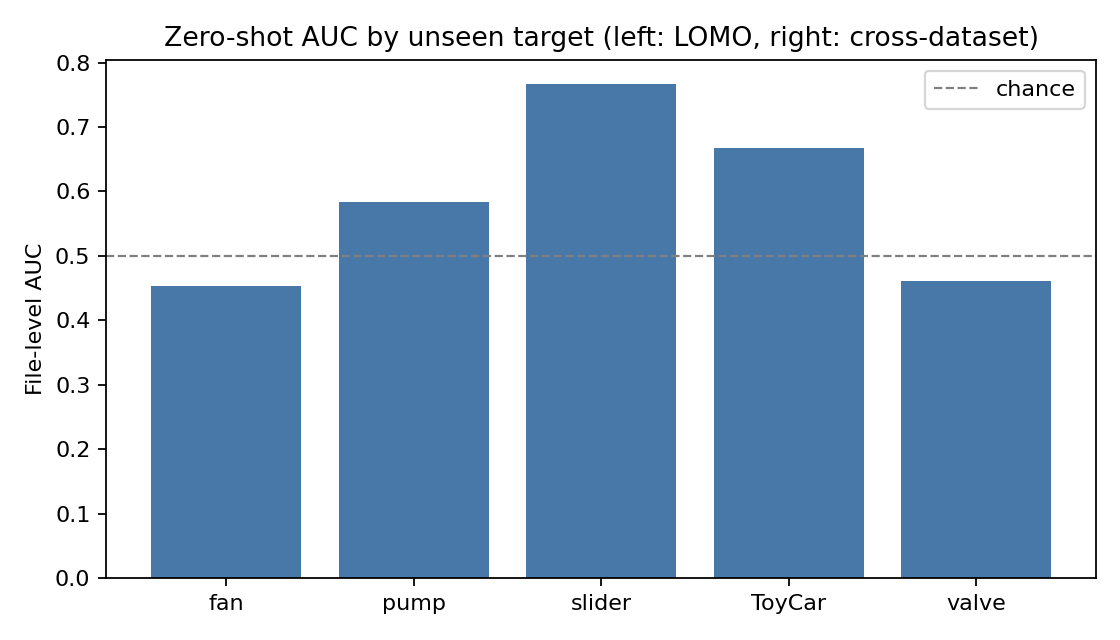

In [10]:
# Cell 8 — Report tables + degradation plot
%cd /content/zsfd
!python -m src.make_report_tables --results results/results.csv
print(open("results/tables.md").read())
from IPython.display import Image, display
display(Image("results/domain_gap.png"))

In [12]:
!tail -12 /content/zsfd/results/results.csv

slider,fan+pump+valve,3,True,0.3,recon,0.8058,0.5958,4094
slider,fan+pump+valve,3,True,0.3,maha,0.6788,0.5267,4094
slider,fan+pump+valve,3,True,0.3,combined,0.7661,0.5735,4094
ToyCar,fan+pump+slider+valve,4,True,0.3,recon,0.658,0.5226,6459
ToyCar,fan+pump+slider+valve,4,True,0.3,maha,0.6454,0.54,6459
ToyCar,fan+pump+slider+valve,4,True,0.3,combined,0.6672,0.5255,6459
valve,fan+pump+slider,3,True,0.3,recon,0.4408,0.5005,4170
valve,fan+pump+slider,3,True,0.3,maha,0.4379,0.499,4170
valve,fan+pump+slider,3,True,0.3,combined,0.4398,0.4967,4170
valve,fan+pump,2,True,0.3,recon,0.4436,0.5007,4170
valve,fan+pump,2,True,0.3,maha,0.4745,0.5004,4170
valve,fan+pump,2,True,0.3,combined,0.4606,0.5003,4170


In [11]:
# Cell 9 — Package everything for submission
%cd /content/zsfd
!zip -rq /content/submission_results.zip results runs/*/config.json
from google.colab import files
files.download("/content/submission_results.zip")
# Then: paste tables into the report's [FILL AFTER RUNS] blocks,
# regenerate the PDF locally (python report/make_report.py), push code to GitHub, submit the form.

/content/zsfd


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>